Dataset Shape: (1420, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0.0,yes,southwest,16884.92400
1,18,male,33.770,1.0,no,southeast,1725.55230
2,28,male,33.000,3.0,no,southeast,4449.46200
3,33,male,22.705,0.0,no,northwest,21984.47061
4,32,male,28.880,0.0,no,northwest,3866.85520


Median Charges: 9361.3268

Class Distribution:
charges
0    720
1    700
Name: count, dtype: int64
Feature Matrix Shape: (1420, 6)


,age,sex,bmi,children,smoker,region
0,19,female,27.900,0.0,yes,southwest
1,18,male,33.770,1.0,no,southeast
2,28,male,33.000,3.0,no,southeast
3,33,male,22.705,0.0,no,northwest
4,32,male,28.880,0.0,no,northwest


Feature Matrix (X): (1420, 6)
Regression Target (y_reg): (1420,)
Classification Target (y_clf): (1420,)
Categorical Columns:
['sex', 'smoker', 'region']
Encoded Feature Matrix Shape: (1420, 8)


...

Top 3 Features by Absolute Coefficient


,Feature,Coefficient,Absolute_Coefficient
4,smoker_yes,9462.640754,9462.640754
0,age,3931.482052,3931.482052
1,bmi,2003.715122,2003.715122


Ridge Regression Performance
----------------------------
MSE : 42530268.49
R²  : 0.7265


,Model,MSE,R² Score
0,Linear Regression,4.253206e+07,0.726509
1,Ridge Regression,4.253027e+07,0.726520


Training Class Distribution
charges
0    587
1    549
Name: count, dtype: int64

Percentage Distribution
charges
0    51.67
1    48.33
Name: proportion, dtype: float64
Confusion Matrix
[[124   9]
 [ 20 131]]
Accuracy : 0.8979
Classification Report
              precision    recall  f1-score   support

           0       0.86      0.93      0.90       133
           1       0.94      0.87      0.90       151

    accuracy                           0.90       284
   macro avg       0.90      0.90      0.90       284
weighted avg       0.90      0.90      0.90       284

AUC Score : 0.9203


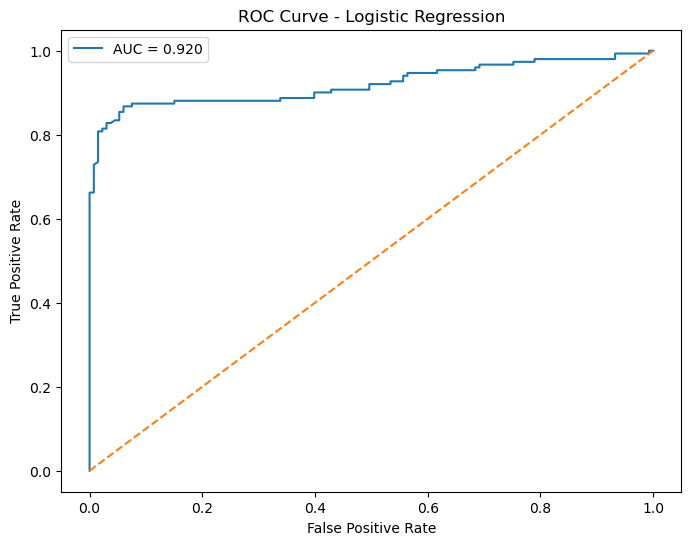

,Threshold,Precision,Recall,F1 Score
0,0.3,0.820988,0.880795,0.849840
1,0.4,0.880000,0.874172,0.877076
2,0.5,0.935714,0.867550,0.900344
3,0.6,0.947368,0.834437,0.887324
4,0.7,0.983333,0.781457,0.870849


Best Threshold Based on F1 Score
0.5


,Metric,C=0.01,C=1.0
0,Precision,0.928058,0.935714
1,Recall,0.854305,0.867550
2,AUC,0.918438,0.920281


Bootstrap Results
-------------------------
Mean AUC Difference : 0.001961
95% CI Lower Bound  : -0.001178
95% CI Upper Bound  : 0.005307
The 95% confidence interval includes zero.
The observed difference may not be statistically reliable.


In [2]:
import pandas as pd
import numpy as np
#Task 1: Load the dataset
df = pd.read_csv("cleaned_data.csv")
print("Dataset Shape:", df.shape)
display(df.head())

#Define regression target variable
y_reg = df["charges"]
# Classification target variable
y_clf = (y_reg > y_reg.median()).astype(int)

print("Median Charges:", y_reg.median())

print("\nClass Distribution:")
print(y_clf.value_counts())

# Feature matrix
X = df.drop(columns=["charges"])
print("Feature Matrix Shape:", X.shape)

display(X.head())

#Verify shapes
print("Feature Matrix (X):", X.shape)
print("Regression Target (y_reg):", y_reg.shape)
print("Classification Target (y_clf):", y_clf.shape)

#Task 2: Categorical Encoding
# Identify categorical columns
categorical_columns = X.select_dtypes(include=["object", "category"]).columns

print("Categorical Columns:")
print(categorical_columns.tolist())

# Apply One-Hot Encoding
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Encoded Feature Matrix Shape:", X.shape)

display(X.head())

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("Regression Training Set:", X_train_reg.shape)
print("Regression Testing Set :", X_test_reg.shape)

# Classification train-test split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42
)
print("Classification Training Set:", X_train_clf.shape)
print("Classification Testing Set :", X_test_clf.shape)

scaler = StandardScaler()
scaler.fit(X_train_reg)

X_train_reg_scaled = scaler.transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

X_train_clf_scaled = X_train_reg_scaled
X_test_clf_scaled = X_test_reg_scaled

print("Mean of scaled training features:")
print(X_train_reg_scaled.mean(axis=0))

print("Standard deviation of scaled training features:")
print(X_train_reg_scaled.std(axis=0))

#Task 4: Regression model:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Create Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_reg_scaled, y_train_reg)

# Predict insurance charges
y_pred_reg = linear_model.predict(X_test_reg_scaled)

# Calculate evaluation metrics
mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("Linear Regression Performance")
print("-----------------------------")
print(f"MSE : {mse:.2f}")
print(f"R²  : {r2:.4f}")

#print model coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

display(coefficients)

top3 = (
#Top 3 largest coefficients
    coefficients
    .assign(Absolute_Coefficient=coefficients["Coefficient"].abs())
    .sort_values("Absolute_Coefficient", ascending=False)
    .head(3)
)

print("Top 3 Features by Absolute Coefficient")

display(top3)

#Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_reg_scaled, y_train_reg)
ridge_predictions = ridge_model.predict(X_test_reg_scaled)

ridge_mse = mean_squared_error(
    y_test_reg,
    ridge_predictions
)

ridge_r2 = r2_score(
    y_test_reg,
    ridge_predictions
)

print("Ridge Regression Performance")
print("----------------------------")
print(f"MSE : {ridge_mse:.2f}")
print(f"R²  : {ridge_r2:.4f}")

#Compare Linear and Ridge Regression
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse, ridge_mse],
    "R² Score": [r2, ridge_r2]
})

display(comparison)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score
)

import matplotlib.pyplot as plt

#check imbalance
print("Training Class Distribution")
print(y_train_clf.value_counts())
print("\nPercentage Distribution")
print(
    (y_train_clf.value_counts(normalize=True)*100).round(2)
)

# Dataset is balanced.
# No imbalance handling is required.
# Train Logistic Regression
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(
    X_train_clf_scaled,
    y_train_clf
)
#Predict class labels
y_pred_clf = logistic_model.predict( X_test_clf_scaled)

#Predict probabilities for ROC curve
y_pred_proba = logistic_model.predict_proba(X_test_clf_scaled)[:,1]

#Confusion Matrix
conf_matrix = confusion_matrix(y_test_clf, y_pred_clf)
print("Confusion Matrix")
print(conf_matrix)

#Accuracy Score
accuracy = accuracy_score(y_test_clf, y_pred_clf)
print(f"Accuracy : {accuracy:.4f}")

#Precision, Recall, F1-Score
class_report = classification_report(y_test_clf, y_pred_clf)
print("Classification Report")
print(class_report)

#AUC
auc_score = roc_auc_score(y_test_clf, y_pred_proba)
print(f"AUC Score : {auc_score:.4f}")

#ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_clf, y_pred_proba)
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

#Decision threshold analysis
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]
results = []

for threshold in thresholds:

    # Convert probabilities into predicted classes
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    precision = precision_score(y_test_clf, y_pred_threshold)
    recall = recall_score(y_test_clf, y_pred_threshold)
    f1 = f1_score(y_test_clf, y_pred_threshold)

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

threshold_results = pd.DataFrame(results)

display(threshold_results)
#find the threshold with the highest F1 score
best_threshold_row = threshold_results.loc[threshold_results["F1 Score"].idxmax()]
best_threshold = best_threshold_row["Threshold"]
print("Best Threshold Based on F1 Score")
print(best_threshold)

#Task 6: Regularization experiment on Logistic Regression

logistic_model_c001 = LogisticRegression(
    C=0.01,
    max_iter=1000
)

logistic_model_c001.fit(
    X_train_clf_scaled,
    y_train_clf
)
#Predict class labels and probabilities for the model with C=0.01
y_pred_c001 = logistic_model_c001.predict(
    X_test_clf_scaled
)
#Predict probabilities
y_pred_proba_c001 = logistic_model_c001.predict_proba(
    X_test_clf_scaled
)[:,1]
#Compute metrics:
from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score
)

precision_c001 = precision_score(
    y_test_clf,
    y_pred_c001
)

recall_c001 = recall_score(
    y_test_clf,
    y_pred_c001
)

auc_c001 = roc_auc_score(
    y_test_clf,
    y_pred_proba_c001
)
#Baseline Metrics
precision_c1 = precision_score(
    y_test_clf,
    y_pred_clf
)

recall_c1 = recall_score(
    y_test_clf,
    y_pred_clf
)

auc_c1 = roc_auc_score(
    y_test_clf,
    y_pred_proba
)

#Compare both models
comparison_metrics = pd.DataFrame({
    "Metric": ["Precision", "Recall", "AUC"],
    "C=0.01": [precision_c001, recall_c001, auc_c001],
    "C=1.0": [precision_c1, recall_c1, auc_c1]
})

display(comparison_metrics)
#Task 7: Bootstrap confidence interval for AUC differenc
auc_differences = []
for i in range(500):

    # Generate bootstrap sample indices
    sample_indices = np.random.choice(
        len(y_test_clf),
        size=len(y_test_clf),
        replace=True
    )

    # Bootstrap true labels
    y_bootstrap = y_test_clf.iloc[sample_indices]

    # Bootstrap predicted probabilities
    proba_c1 = y_pred_proba[sample_indices]

    proba_c001 = y_pred_proba_c001[sample_indices]

    # Skip samples containing only one class
    if len(np.unique(y_bootstrap)) < 2:
        continue

    auc_c1 = roc_auc_score(
        y_bootstrap,
        proba_c1
    )

    auc_c001 = roc_auc_score(
        y_bootstrap,
        proba_c001
    )

    auc_differences.append(
        auc_c1 - auc_c001
    )

#Compute statistics
mean_difference = np.mean(auc_differences)

lower_ci = np.percentile(
    auc_differences,
    2.5
)

upper_ci = np.percentile(
    auc_differences,
    97.5
)
print("Bootstrap Results")
print("-------------------------")
print(f"Mean AUC Difference : {mean_difference:.6f}")
print(f"95% CI Lower Bound  : {lower_ci:.6f}")
print(f"95% CI Upper Bound  : {upper_ci:.6f}")

if lower_ci > 0 or upper_ci < 0:
    print("The 95% confidence interval excludes zero.")
    print("The advantage of C=1.0 is likely consistent.")
else:
    print("The 95% confidence interval includes zero.")
    print("The observed difference may not be statistically reliable.")

